# 02_LSTM_FD003 — LSTM baseline, C-MAPSS FD003

**Protocol:** `README.md` v1.0 (locked 2026-09-28) — Notebook 2 of 4 (`01_LSTM_FD001`, `02_LSTM_FD003`, `03_XGB_FD001`, `04_XGB_FD003`).
**Model:** LSTM | **Dataset:** FD003 | **Training:** Google Colab, GPU T4 | **Inference-latency benchmark:** CPU only (see S16).

Run this notebook top to bottom ("Restart & Run All") before saving results. Do not change hyper-parameters
after seeing S15 (test evaluation) — see README section 11 (Deviation policy).

## S1 — Environment

In [1]:
# S1 — Environment: installs, imports, version logging
import os, sys, json, time, platform, hashlib, random, subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

print("Python      :", sys.version.split()[0])
print("NumPy       :", np.__version__)
print("Pandas      :", pd.__version__)
print("PyTorch     :", torch.__version__)
print("CUDA avail. :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU         :", torch.cuda.get_device_name(0))

try:
    cpu_model = subprocess.check_output("cat /proc/cpuinfo | grep 'model name' | uniq", shell=True).decode().strip()
except Exception:
    cpu_model = platform.processor() or "unknown"
print("CPU         :", cpu_model)


Python      : 3.13.15
NumPy       : 2.1.3
Pandas      : 2.2.3
PyTorch     : 2.11.0+cu128
CUDA avail. : True
GPU         : Tesla T4
CPU         : model name	: Intel(R) Xeon(R) CPU @ 2.00GHz


## S2 — Drive & paths

In [2]:
# S2 — Drive & paths
from google.colab import drive
drive.mount('/content/drive')

DATASET_ID = "FD003"
MODEL_NAME = "LSTM"

BASE_DIR    = "/content/drive/MyDrive/RUL_Prediction_CMAPSS_FD001_003"
DATA_DIR    = os.path.join(BASE_DIR, "RUL_Prediction_003")   # raw train/test/RUL files live here
RESULTS_DIR = os.path.join(BASE_DIR, "results", f"{MODEL_NAME}_{DATASET_ID}")
MODELS_DIR  = os.path.join(RESULTS_DIR, "models")
FIGS_DIR    = os.path.join(RESULTS_DIR, "figures")

for d in (RESULTS_DIR, MODELS_DIR, FIGS_DIR):
    os.makedirs(d, exist_ok=True)

assert os.path.isdir(DATA_DIR), f"Data folder not found: {DATA_DIR} — check the Drive folder name."
print("BASE_DIR   :", BASE_DIR)
print("DATA_DIR   :", DATA_DIR)
print("RESULTS_DIR:", RESULTS_DIR)
print("Files in DATA_DIR:", sorted(os.listdir(DATA_DIR)))


Mounted at /content/drive
BASE_DIR   : /content/drive/MyDrive/RUL_Prediction_CMAPSS_FD001_003
DATA_DIR   : /content/drive/MyDrive/RUL_Prediction_CMAPSS_FD001_003/RUL_Prediction_003
RESULTS_DIR: /content/drive/MyDrive/RUL_Prediction_CMAPSS_FD001_003/results/LSTM_FD003
Files in DATA_DIR: ['RUL_FD003.txt', 'test_FD003.txt', 'train_FD003.txt']


## S3 — Configuration (fixed by README.md, not tuned per dataset)

In [3]:
# S3 — Configuration
CONFIG = {
    "dataset_id": DATASET_ID,
    "model": MODEL_NAME,

    # ---- data ----
    "sensor_cols": ["s2","s3","s4","s7","s8","s9","s11","s12","s13",
                    "s14","s15","s17","s20","s21"],
    "rul_clip": 125,
    "window_size": 30,
    "val_fraction": 0.20,
    "split_seed": 42,

    # ---- LSTM architecture (identical for FD001 and FD003) ----
    "hidden_size": 64,
    "num_layers": 2,
    "dropout": 0.2,
    "fc_hidden": 32,

    # ---- training ----
    "batch_size": 64,
    "lr": 1e-3,
    "weight_decay": 0.0,
    "grad_clip_norm": 1.0,
    "max_epochs": 100,
    "early_stopping_patience": 10,

    # ---- repetitions ----
    "seeds": [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],

    # ---- efficiency benchmark ----
    "latency_warmup_calls": 50,
    "latency_timed_calls": 1000,
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training device: {device}")
print(json.dumps(CONFIG, indent=2))


Training device: cuda
{
  "dataset_id": "FD003",
  "model": "LSTM",
  "sensor_cols": [
    "s2",
    "s3",
    "s4",
    "s7",
    "s8",
    "s9",
    "s11",
    "s12",
    "s13",
    "s14",
    "s15",
    "s17",
    "s20",
    "s21"
  ],
  "rul_clip": 125,
  "window_size": 30,
  "val_fraction": 0.2,
  "split_seed": 42,
  "hidden_size": 64,
  "num_layers": 2,
  "dropout": 0.2,
  "fc_hidden": 32,
  "batch_size": 64,
  "lr": 0.001,
  "weight_decay": 0.0,
  "grad_clip_norm": 1.0,
  "max_epochs": 100,
  "early_stopping_patience": 10,
  "seeds": [
    0,
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9
  ],
  "latency_warmup_calls": 50,
  "latency_timed_calls": 1000
}


## S4 — Reproducibility helpers

In [4]:
# S4 — Reproducibility
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def sha256_of_array(arr: np.ndarray) -> str:
    return hashlib.sha256(np.ascontiguousarray(arr).tobytes()).hexdigest()

def sha256_of_file(path: str) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            h.update(chunk)
    return h.hexdigest()


## S5 — Load raw data

In [5]:
# S5 — Load raw data
train_path = os.path.join(DATA_DIR, f"train_{DATASET_ID}.txt")
test_path  = os.path.join(DATA_DIR, f"test_{DATASET_ID}.txt")
rul_path   = os.path.join(DATA_DIR, f"RUL_{DATASET_ID}.txt")

for p in (train_path, test_path, rul_path):
    assert os.path.isfile(p), f"Missing file: {p}"

raw_checksums = {
    os.path.basename(train_path): sha256_of_file(train_path),
    os.path.basename(test_path):  sha256_of_file(test_path),
    os.path.basename(rul_path):   sha256_of_file(rul_path),
}
print("Raw file SHA-256 (record these in data/README.md):")
for k, v in raw_checksums.items():
    print(f"  {k}: {v}")

col_names = ["unit_number", "time_in_cycles",
             "op_setting_1", "op_setting_2", "op_setting_3"] + [f"s{i}" for i in range(1, 22)]

train_df = pd.read_csv(train_path, sep=r"\s+", header=None, names=col_names)
test_df  = pd.read_csv(test_path,  sep=r"\s+", header=None, names=col_names)
rul_df   = pd.read_csv(rul_path,   sep=r"\s+", header=None, names=["RUL"])

n_train_engines = train_df["unit_number"].nunique()
n_test_engines  = test_df["unit_number"].nunique()
print(f"Train engines: {n_train_engines} (expected 100)")
print(f"Test engines : {n_test_engines} (expected 100)")
assert n_train_engines == 100 and n_test_engines == 100, "Unexpected engine count — check the raw files."
assert len(rul_df) == n_test_engines, "RUL file length must match number of test engines."


Raw file SHA-256 (record these in data/README.md):
  train_FD003.txt: 2abbe9968cc5e8eb091980f51b20f62bb4127336d3482cb52071d53bf23329e2
  test_FD003.txt: 299babd63c8d987cef079c4a425429f33b3a34797d803bbe2ad48c29dbd0d790
  RUL_FD003.txt: df1e0566306b174a2de41c67a3e7a51877889598b78643fc3e5685259091b7cb
Train engines: 100 (expected 100)
Test engines : 100 (expected 100)


## S6 — RUL labels (piece-wise linear, clipped at 125)

In [6]:
# S6 — RUL labels
def add_train_rul(df: pd.DataFrame, clip: int) -> pd.DataFrame:
    max_cycle = df.groupby("unit_number")["time_in_cycles"].transform("max")
    df = df.copy()
    df["RUL_raw"] = max_cycle - df["time_in_cycles"]
    df["RUL"] = df["RUL_raw"].clip(upper=clip)
    return df

train_df = add_train_rul(train_df, CONFIG["rul_clip"])

# Test RUL: RUL_FD00X.txt gives the true RUL at the LAST observed cycle of each engine.
test_rul_raw = rul_df["RUL"].to_numpy().astype(np.float32)          # secondary target (unclipped)
test_rul_clipped = np.clip(test_rul_raw, a_min=None, a_max=CONFIG["rul_clip"]).astype(np.float32)  # primary target

print("Train RUL (clipped) stats:", train_df["RUL"].describe()[["min","mean","max"]].to_dict())
print("Test RUL (raw) stats     :", pd.Series(test_rul_raw).describe()[["min","mean","max"]].to_dict())


Train RUL (clipped) stats: {'min': 0.0, 'mean': 93.14320388349515, 'max': 125.0}
Test RUL (raw) stats     : {'min': 6.0, 'mean': 75.31999969482422, 'max': 145.0}


## S7 — Feature check (14-sensor list, per README section 4)

In [7]:
# S7 — Feature check
all_sensor_cols = [f"s{i}" for i in range(1, 22)]
dropped_sensors = [c for c in all_sensor_cols if c not in CONFIG["sensor_cols"]]
assert len(CONFIG["sensor_cols"]) == 14, "Protocol fixes 14 input sensors."

variance_table = train_df[all_sensor_cols].var().sort_values()
print("Variance of sensors dropped by the protocol (expected near-zero):")
print(variance_table[dropped_sensors])
print()
print("Variance of sensors kept by the protocol (expected non-trivial):")
print(variance_table[CONFIG["sensor_cols"]])

low_variance_but_kept = [c for c in CONFIG["sensor_cols"] if variance_table[c] < 1e-8]
if low_variance_but_kept:
    print("\nNOTE — discrepancy vs. the protocol's variance assumption, sensors kept by protocol but near-zero variance here:",
          low_variance_but_kept, "(reported as-is, feature list not changed silently — see README S7.)")


Variance of sensors dropped by the protocol (expected near-zero):
s1     4.468817e-21
s5     1.297818e-23
s6     3.281895e-04
s10    1.214417e-05
s16    3.063800e-28
s18    0.000000e+00
s19    0.000000e+00
dtype: float64

Variance of sensors kept by the protocol (expected non-trivial):
s2       0.273562
s3      46.381794
s4      95.515015
s7      11.815326
s8       0.025054
s9     399.212161
s11      0.090045
s12     10.597069
s13      0.025002
s14    272.385900
s15      0.003662
s17      3.102736
s20      0.061934
s21      0.022271
dtype: float64


## S8 — Validation split (by engine, 80/20, split_seed=42)

In [8]:
# S8 — Engine split
all_engines = np.sort(train_df["unit_number"].unique())
rng = np.random.RandomState(CONFIG["split_seed"])
perm = rng.permutation(all_engines)

n_val = int(round(len(all_engines) * CONFIG["val_fraction"]))
val_engines = np.sort(perm[:n_val])
train_engines = np.sort(perm[n_val:])

print(f"Train engines ({len(train_engines)}):", train_engines.tolist())
print(f"Val engines   ({len(val_engines)}):", val_engines.tolist())

val_engines_hash = hashlib.sha256(val_engines.tobytes()).hexdigest()
print("Validation-engine-set hash (must match 04_XGB_FD003):", val_engines_hash)

train_split_df = train_df[train_df["unit_number"].isin(train_engines)].reset_index(drop=True)
val_split_df   = train_df[train_df["unit_number"].isin(val_engines)].reset_index(drop=True)


Train engines (80): [2, 3, 4, 6, 7, 8, 9, 10, 12, 14, 15, 16, 17, 18, 20, 21, 22, 24, 25, 26, 27, 28, 29, 30, 33, 35, 36, 37, 38, 39, 41, 42, 43, 44, 47, 48, 49, 50, 51, 52, 53, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 72, 73, 75, 76, 79, 80, 82, 83, 85, 86, 87, 88, 89, 90, 92, 93, 94, 95, 96, 97, 98, 99, 100]
Val engines   (20): [1, 5, 11, 13, 19, 23, 31, 32, 34, 40, 45, 46, 54, 71, 74, 77, 78, 81, 84, 91]
Validation-engine-set hash (must match 04_XGB_FD003): e805177b4036c7b14abff995cf89af03b5a325e2c37e319463d8027b05002126


## S9 — Scaling (StandardScaler, fit on the 80 training engines only)

In [9]:
# S9 — Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(train_split_df[CONFIG["sensor_cols"]])

def scale_df(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out[CONFIG["sensor_cols"]] = scaler.transform(df[CONFIG["sensor_cols"]])
    return out

train_split_scaled = scale_df(train_split_df)
val_split_scaled   = scale_df(val_split_df)
test_scaled         = scale_df(test_df)

print("Scaler fitted on", train_split_df.shape[0], "rows from", len(train_engines), "engines.")
print("Scaled feature mean (train, should be ~0):", train_split_scaled[CONFIG["sensor_cols"]].mean().mean().round(4))


Scaler fitted on 20012 rows from 80 engines.
Scaled feature mean (train, should be ~0): 0.0


## S10 — Windowing (length 30, stride 1, never crosses engine boundaries)

In [10]:
# S10 — Windowing
W = CONFIG["window_size"]
FEATS = CONFIG["sensor_cols"]

def make_windows(df: pd.DataFrame, window: int):
    X_list, y_list = [], []
    for _, g in df.sort_values("time_in_cycles").groupby("unit_number"):
        vals = g[FEATS].to_numpy(dtype=np.float32)
        ruls = g["RUL"].to_numpy(dtype=np.float32)
        n = len(g)
        if n < window:
            continue  # protocol: no padding (README S4 — Test input)
        for end in range(window, n + 1):
            X_list.append(vals[end - window:end])
            y_list.append(ruls[end - 1])
    return np.stack(X_list).astype(np.float32), np.array(y_list, dtype=np.float32)

def make_test_last_window(df: pd.DataFrame, window: int):
    X_list, engine_ids = [], []
    skipped = []
    for uid, g in df.sort_values("time_in_cycles").groupby("unit_number"):
        vals = g[FEATS].to_numpy(dtype=np.float32)
        if len(g) < window:
            skipped.append(uid)
            continue
        X_list.append(vals[-window:])
        engine_ids.append(uid)
    assert not skipped, f"Test engines with fewer than {window} cycles (no padding allowed): {skipped}"
    return np.stack(X_list).astype(np.float32), np.array(engine_ids)

X_train, y_train = make_windows(train_split_scaled, W)
X_val,   y_val   = make_windows(val_split_scaled, W)
X_test, test_engine_ids = make_test_last_window(test_scaled, W)

# align y_test to the (primary=clipped, secondary=raw) targets, ordered by test_engine_ids
order = np.argsort(test_engine_ids)
X_test = X_test[order]
test_engine_ids = test_engine_ids[order]
y_test_clipped = test_rul_clipped[test_engine_ids - 1]   # engine IDs are 1-indexed
y_test_raw     = test_rul_raw[test_engine_ids - 1]

print("X_train:", X_train.shape, " y_train:", y_train.shape)
print("X_val  :", X_val.shape,   " y_val  :", y_val.shape)
print("X_test :", X_test.shape, " y_test_clipped:", y_test_clipped.shape)


X_train: (17692, 30, 14)  y_train: (17692,)
X_val  : (4128, 30, 14)  y_val  : (4128,)
X_test : (100, 30, 14)  y_test_clipped: (100,)


## S11 — Data fingerprints (must match `04_XGB_FD003` on the same dataset)

In [11]:
# S11 — Fingerprints
fingerprint = {
    "dataset_id": DATASET_ID,
    "X_train": sha256_of_array(X_train),
    "y_train": sha256_of_array(y_train),
    "X_val":   sha256_of_array(X_val),
    "y_val":   sha256_of_array(y_val),
    "X_test":  sha256_of_array(X_test),
    "y_test_raw":     sha256_of_array(y_test_raw),
    "y_test_clipped": sha256_of_array(y_test_clipped),
    "val_engines_hash": val_engines_hash,
}
with open(os.path.join(RESULTS_DIR, "fingerprint.json"), "w") as f:
    json.dump(fingerprint, f, indent=2)

print(json.dumps(fingerprint, indent=2))


{
  "dataset_id": "FD003",
  "X_train": "8d25639a18dd77b7c0fcf3199fe46163230d6d7ebca35127167d945de11118ab",
  "y_train": "48074f9ae8ee0964a3331d7cb7e5e0d79cfdc01e2a5d3b78d8a380ec97d28683",
  "X_val": "1ed0de409558f014dec8545fd77f63cf72c0982255afb1d2709366c6453944a8",
  "y_val": "310ab2418da2257ce864d053a16341d34399e9ed2fb453b10f8141c4da04cdb7",
  "X_test": "c610c2a501039268adc3eb112c082858bbfe3072259924d0668c2d5a7c381e15",
  "y_test_raw": "ef4b95e6f5b30c084f9b6f92f9896aa7341b33ebe23a81d417bb7213c4da76b9",
  "y_test_clipped": "47d137353f794064864cd0e6ecfb46371c4170f62947819567962aee48adf94f",
  "val_engines_hash": "e805177b4036c7b14abff995cf89af03b5a325e2c37e319463d8027b05002126"
}


## S12 — Model definition (LSTM)

In [12]:
# S12 — Model definition
class LSTMRegressor(nn.Module):
    def __init__(self, n_features, hidden_size, num_layers, dropout, fc_hidden):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc1 = nn.Linear(hidden_size, fc_hidden)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(fc_hidden, 1)

    def forward(self, x):
        out, (h_n, _) = self.lstm(x)
        last = out[:, -1, :]
        z = self.relu(self.fc1(last))
        return self.fc2(z).squeeze(-1)

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

_probe = LSTMRegressor(len(FEATS), CONFIG["hidden_size"], CONFIG["num_layers"],
                        CONFIG["dropout"], CONFIG["fc_hidden"])
n_params = count_params(_probe)
print("Trainable parameters:", n_params)
assert n_params == 55_873, f"Parameter count changed ({n_params}) — architecture drifted from README S6."
del _probe


Trainable parameters: 55873


## S13 — Single-seed dry run (sanity check on train/val only, test set untouched)

In [13]:
# S13 — Single-seed dry run
def to_loader(X, y, batch_size, shuffle):
    ds = TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=False)

set_seed(CONFIG["seeds"][0])
dry_model = LSTMRegressor(len(FEATS), CONFIG["hidden_size"], CONFIG["num_layers"],
                           CONFIG["dropout"], CONFIG["fc_hidden"]).to(device)
opt = torch.optim.Adam(dry_model.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])
loss_fn = nn.MSELoss()

train_loader = to_loader(X_train, y_train, CONFIG["batch_size"], shuffle=True)
val_loader   = to_loader(X_val, y_val, CONFIG["batch_size"], shuffle=False)

dry_train_losses, dry_val_losses = [], []
for epoch in range(5):
    dry_model.train()
    running = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        pred = dry_model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(dry_model.parameters(), CONFIG["grad_clip_norm"])
        opt.step()
        running += loss.item() * len(xb)
    train_rmse = (running / len(train_loader.dataset)) ** 0.5
    dry_model.eval()
    running_val = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = dry_model(xb)
            running_val += loss_fn(pred, yb).item() * len(xb)
    val_rmse = (running_val / len(val_loader.dataset)) ** 0.5
    dry_train_losses.append(train_rmse)
    dry_val_losses.append(val_rmse)
    print(f"[dry run] epoch {epoch+1}/5  train RMSE={train_rmse:.2f}  val RMSE={val_rmse:.2f}")

assert dry_train_losses[-1] < dry_train_losses[0], (
    "Training RMSE did not decrease over 5 epochs — treat as a bug (data/shape/scaling), "
    "per README S6 sanity-check rule. Do not proceed to S14 until this is fixed."
)
del dry_model, opt
print("\nSanity check passed — training loss is decreasing. Proceeding to full multi-seed training.")


[dry run] epoch 1/5  train RMSE=70.62  val RMSE=21.99
[dry run] epoch 2/5  train RMSE=16.71  val RMSE=13.86
[dry run] epoch 3/5  train RMSE=13.69  val RMSE=13.91
[dry run] epoch 4/5  train RMSE=12.29  val RMSE=14.08
[dry run] epoch 5/5  train RMSE=11.41  val RMSE=13.26

Sanity check passed — training loss is decreasing. Proceeding to full multi-seed training.


## S14 — Multi-seed training (10 seeds, early stopping on validation RMSE)

In [14]:
# S14 — Multi-seed training
def train_one_seed(seed):
    set_seed(seed)
    model = LSTMRegressor(len(FEATS), CONFIG["hidden_size"], CONFIG["num_layers"],
                           CONFIG["dropout"], CONFIG["fc_hidden"]).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])
    loss_fn = nn.MSELoss()

    train_loader = to_loader(X_train, y_train, CONFIG["batch_size"], shuffle=True)
    val_loader   = to_loader(X_val, y_val, CONFIG["batch_size"], shuffle=False)

    best_val_rmse = float("inf")
    best_state = None
    best_epoch = -1
    patience_left = CONFIG["early_stopping_patience"]
    history = []

    t0 = time.time()
    for epoch in range(CONFIG["max_epochs"]):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), CONFIG["grad_clip_norm"])
            opt.step()

        model.eval()
        running_val = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb)
                running_val += loss_fn(pred, yb).item() * len(xb)
        val_rmse = (running_val / len(val_loader.dataset)) ** 0.5
        history.append(val_rmse)

        if val_rmse < best_val_rmse - 1e-4:
            best_val_rmse = val_rmse
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_epoch = epoch
            patience_left = CONFIG["early_stopping_patience"]
        else:
            patience_left -= 1
            if patience_left <= 0:
                break

    train_time = time.time() - t0
    model.load_state_dict(best_state)
    return model, {"seed": seed, "best_epoch": best_epoch, "best_val_rmse": best_val_rmse,
                   "epochs_run": len(history), "train_time_sec": train_time,
                   "val_rmse_history": history}

seed_models = {}
seed_logs = []
for seed in CONFIG["seeds"]:
    model, log = train_one_seed(seed)
    seed_models[seed] = model
    seed_logs.append(log)
    torch.save(model.state_dict(), os.path.join(MODELS_DIR, f"lstm_seed{seed}.pth"))
    print(f"seed={seed}  best_epoch={log['best_epoch']}  best_val_rmse={log['best_val_rmse']:.3f}  "
          f"epochs_run={log['epochs_run']}  time={log['train_time_sec']:.1f}s")

with open(os.path.join(RESULTS_DIR, "training_log.json"), "w") as f:
    json.dump(seed_logs, f, indent=2)


seed=0  best_epoch=10  best_val_rmse=12.330  epochs_run=21  time=23.5s
seed=1  best_epoch=5  best_val_rmse=12.563  epochs_run=16  time=20.5s
seed=2  best_epoch=5  best_val_rmse=12.653  epochs_run=16  time=18.9s
seed=3  best_epoch=9  best_val_rmse=12.619  epochs_run=20  time=23.7s
seed=4  best_epoch=5  best_val_rmse=12.373  epochs_run=16  time=18.2s
seed=5  best_epoch=2  best_val_rmse=11.943  epochs_run=13  time=15.2s
seed=6  best_epoch=8  best_val_rmse=12.088  epochs_run=19  time=22.2s
seed=7  best_epoch=4  best_val_rmse=12.131  epochs_run=15  time=16.8s
seed=8  best_epoch=5  best_val_rmse=12.229  epochs_run=16  time=18.5s
seed=9  best_epoch=6  best_val_rmse=12.223  epochs_run=17  time=19.7s


## S15 — Test evaluation (used once per seed, after training)

In [15]:
# S15 — Test evaluation
def nasa_score(y_true, y_pred):
    d = y_pred - y_true
    s = np.where(d < 0, np.exp(-d / 13.0) - 1.0, np.exp(d / 10.0) - 1.0)
    return float(np.sum(s))

def eval_metrics(y_true, y_pred):
    err = y_pred - y_true
    rmse = float(np.sqrt(np.mean(err ** 2)))
    mae = float(np.mean(np.abs(err)))
    score = nasa_score(y_true, y_pred)
    abs_err = np.abs(err)
    tol = {f"within_{k}": float(np.mean(abs_err <= k)) for k in (5, 10, 15)}
    return {"rmse": rmse, "mae": mae, "nasa_score": score, **tol}

X_test_t = torch.from_numpy(X_test)
per_seed_rows = []
per_seed_predictions = {}

for seed in CONFIG["seeds"]:
    model = seed_models[seed].to(device).eval()
    with torch.no_grad():
        y_pred = model(X_test_t.to(device)).cpu().numpy()
    per_seed_predictions[seed] = y_pred

    m_primary = eval_metrics(y_test_clipped, y_pred)
    m_secondary = eval_metrics(y_test_raw, y_pred)
    row = {"seed": seed}
    row.update({f"primary_{k}": v for k, v in m_primary.items()})
    row.update({f"secondary_{k}": v for k, v in m_secondary.items()})
    per_seed_rows.append(row)

metrics_per_seed = pd.DataFrame(per_seed_rows)
print(metrics_per_seed.round(3))

summary = {
    "primary_target": "RUL_clipped_125",
    "secondary_target": "RUL_raw",
}
for col in ["primary_rmse","primary_mae","primary_nasa_score",
            "primary_within_5","primary_within_10","primary_within_15",
            "secondary_rmse","secondary_mae","secondary_nasa_score"]:
    summary[col] = {"mean": float(metrics_per_seed[col].mean()), "std": float(metrics_per_seed[col].std())}

print(json.dumps(summary, indent=2))

predictions_df = pd.DataFrame({"engine_id": test_engine_ids,
                                "y_true_clipped": y_test_clipped,
                                "y_true_raw": y_test_raw})
for seed in CONFIG["seeds"]:
    predictions_df[f"y_pred_seed{seed}"] = per_seed_predictions[seed]
predictions_df["y_pred_mean"] = predictions_df[[f"y_pred_seed{s}" for s in CONFIG['seeds']]].mean(axis=1)


   seed  primary_rmse  primary_mae  primary_nasa_score  primary_within_5  \
0     0        14.352       10.237             703.752              0.44   
1     1        14.084       10.129             622.306              0.42   
2     2        14.735        9.867             886.945              0.50   
3     3        14.669        9.631             828.216              0.48   
4     4        13.739        9.755             518.169              0.43   
5     5        15.589       11.332            1266.890              0.33   
6     6        13.449        8.996             986.302              0.46   
7     7        13.352        9.273             555.070              0.40   
8     8        13.760        9.019             804.041              0.46   
9     9        14.257        9.712            1012.784              0.44   

   primary_within_10  primary_within_15  secondary_rmse  secondary_mae  \
0               0.59               0.77          15.497         11.791   
1              

## S16 — Efficiency (size, parameters, training time, CPU-only inference latency)

In [16]:
# S16 — Efficiency
# Model size on disk (one representative seed, e.g. seed 0)
model_path_seed0 = os.path.join(MODELS_DIR, "lstm_seed0.pth")
model_size_bytes = os.path.getsize(model_path_seed0)

mean_train_time = float(np.mean([log["train_time_sec"] for log in seed_logs]))
mean_epochs = float(np.mean([log["epochs_run"] for log in seed_logs]))

# CPU-only inference latency benchmark (per README S9 — training uses GPU T4, latency uses CPU)
cpu_model_for_latency = LSTMRegressor(len(FEATS), CONFIG["hidden_size"], CONFIG["num_layers"],
                                       CONFIG["dropout"], CONFIG["fc_hidden"])
cpu_model_for_latency.load_state_dict(torch.load(model_path_seed0, map_location="cpu"))
cpu_model_for_latency.eval()
torch.set_num_threads(1)

single_sample = X_test_t[:1]
full_batch = X_test_t

def timed_inference(model, x, warmup, timed):
    with torch.no_grad():
        for _ in range(warmup):
            model(x)
        times = []
        for _ in range(timed):
            t0 = time.perf_counter()
            model(x)
            times.append(time.perf_counter() - t0)
    return np.array(times)

lat_single = timed_inference(cpu_model_for_latency, single_sample,
                              CONFIG["latency_warmup_calls"], CONFIG["latency_timed_calls"])
lat_batch = timed_inference(cpu_model_for_latency, full_batch,
                             CONFIG["latency_warmup_calls"], CONFIG["latency_timed_calls"])

efficiency = {
    "model_size_bytes_seed0": model_size_bytes,
    "trainable_parameters": n_params,
    "mean_training_time_sec": mean_train_time,
    "mean_epochs_run": mean_epochs,
    "cpu_latency_single_sample_ms": {
        "median": float(np.median(lat_single) * 1000),
        "p95": float(np.percentile(lat_single, 95) * 1000),
    },
    "cpu_latency_full_batch_per_sample_ms": {
        "median": float(np.median(lat_batch) / len(full_batch) * 1000),
        "p95": float(np.percentile(lat_batch, 95) / len(full_batch) * 1000),
    },
    "cpu_threads": 1,
}
print(json.dumps(efficiency, indent=2))


{
  "model_size_bytes_seed0": 226938,
  "trainable_parameters": 55873,
  "mean_training_time_sec": 19.718414211273192,
  "mean_epochs_run": 16.9,
  "cpu_latency_single_sample_ms": {
    "median": 0.8064720000220404,
    "p95": 1.0870319001128337
  },
  "cpu_latency_full_batch_per_sample_ms": {
    "median": 0.049077104999923904,
    "p95": 0.09364486850040521
  },
  "cpu_threads": 1
}


## S17 — Save results

In [17]:
# S17 — Save results
metrics_per_seed.to_csv(os.path.join(RESULTS_DIR, "metrics_per_seed.csv"), index=False)
predictions_df.to_csv(os.path.join(RESULTS_DIR, "predictions.csv"), index=False)

with open(os.path.join(RESULTS_DIR, "summary.json"), "w") as f:
    json.dump({"summary_metrics": summary, "efficiency": efficiency}, f, indent=2)

with open(os.path.join(RESULTS_DIR, "config.json"), "w") as f:
    json.dump(CONFIG, f, indent=2)

with open(os.path.join(RESULTS_DIR, "env.json"), "w") as f:
    json.dump({
        "python": sys.version.split()[0],
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "torch": torch.__version__,
        "cuda_available": torch.cuda.is_available(),
        "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
        "cpu": cpu_model,
        "raw_file_checksums": raw_checksums,
    }, f, indent=2)

print("Saved to:", RESULTS_DIR)
print(sorted(os.listdir(RESULTS_DIR)))


Saved to: /content/drive/MyDrive/RUL_Prediction_CMAPSS_FD001_003/results/LSTM_FD003
['config.json', 'env.json', 'figures', 'fingerprint.json', 'metrics_per_seed.csv', 'models', 'predictions.csv', 'summary.json', 'training_log.json']


## S18 — Figures

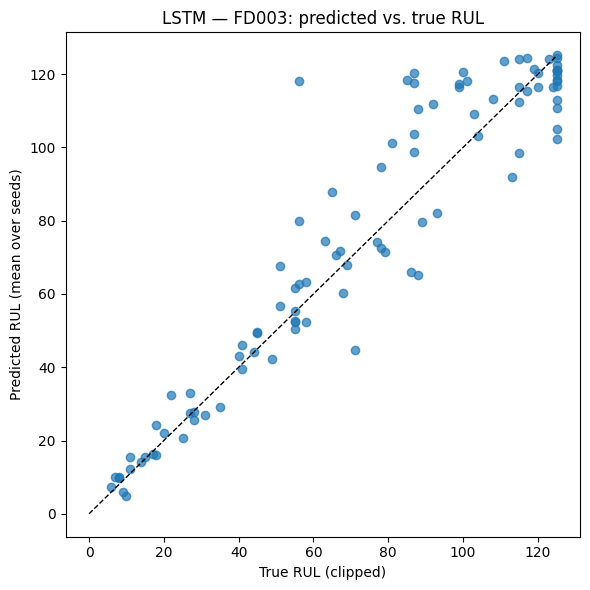

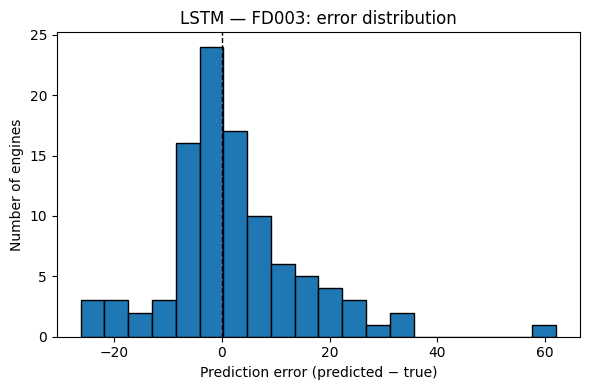

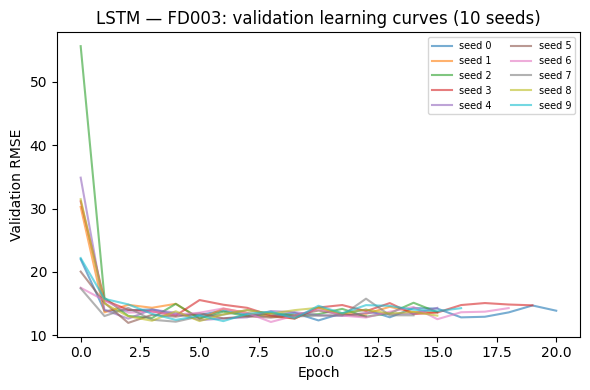

Figures saved to: /content/drive/MyDrive/RUL_Prediction_CMAPSS_FD001_003/results/LSTM_FD003/figures


In [18]:
# S18 — Figures
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(predictions_df["y_true_clipped"], predictions_df["y_pred_mean"], alpha=0.7)
lims = [0, CONFIG["rul_clip"]]
ax.plot(lims, lims, "k--", linewidth=1)
ax.set_xlabel("True RUL (clipped)")
ax.set_ylabel("Predicted RUL (mean over seeds)")
ax.set_title(f"LSTM — {DATASET_ID}: predicted vs. true RUL")
fig.tight_layout()
fig.savefig(os.path.join(FIGS_DIR, "pred_vs_true.png"), dpi=300)
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
errors = predictions_df["y_pred_mean"] - predictions_df["y_true_clipped"]
ax.hist(errors, bins=20, edgecolor="black")
ax.axvline(0, color="k", linestyle="--", linewidth=1)
ax.set_xlabel("Prediction error (predicted − true)")
ax.set_ylabel("Number of engines")
ax.set_title(f"LSTM — {DATASET_ID}: error distribution")
fig.tight_layout()
fig.savefig(os.path.join(FIGS_DIR, "error_distribution.png"), dpi=300)
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
for log in seed_logs:
    ax.plot(log["val_rmse_history"], alpha=0.6, label=f"seed {log['seed']}")
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation RMSE")
ax.set_title(f"LSTM — {DATASET_ID}: validation learning curves (10 seeds)")
ax.legend(fontsize=7, ncol=2)
fig.tight_layout()
fig.savefig(os.path.join(FIGS_DIR, "learning_curves.png"), dpi=300)
plt.show()

print("Figures saved to:", FIGS_DIR)
